# Image Classification with CNN (VGG / ResNet) using PyTorch

## Objectives
- Understand transfer learning
- Implement clean training pipeline
- Handle data splitting and K-Fold
- Parametrize architecture
- Follow PyTorch best practices

## Classical Packages

In [1]:
# python -m ipykernel install --user --name fdeepl --display-name "Python (fdeepl)"

In [2]:
# pip install numpy matplotlib pillow jupyter ipykernel tqdm scikit-learn
# ! pip install numpy matplotlib pillow tqdm scikit-learn

In [3]:
# PyTorch with CUDA
# ! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [4]:
# ! pip install opencv-python==4.12.0.88
# ! pip install imagecodecs

In [5]:
# ## test packages
# import torch

# print("CUDA disponible:", torch.cuda.is_available())
# print("Nom GPU:", torch.cuda.get_device_name(0))
# print("Version CUDA torch:", torch.version.cuda)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)

# x = torch.randn(3,3).to(device)
# print(x)

# Extract image patches
# View the corresponding mask
# If the patch contains disease → label = 1
# Otherwise → label = 0
# Save the patch in:
# train/healthy/
# train/diseased/

# Healthy: 2291
# Diseased: 985

## Imports & Reproducibility

In [6]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split, KFold
from tqdm import tqdm

## Seed for reproducibility (BEST PRACTICE)

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Configuration

In [8]:
class Config:
    architecture = "resnet"  # "resnet" or "vgg"
    num_classes = 2
    hidden_dim = 512
    batch_size = 16
    lr = 1e-3
    epochs = 5
    k_folds = 5
    use_kfold = False
    device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()

## Data Preparation

### Pre-split (train and test)

In [10]:
import os
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path


base_dir = Path("/home/adjalil/Working/data_lionel")
raw_dir = base_dir / "data_src" / "raw"
mask_dir = base_dir / "data_src" / "mask"
output_dir = base_dir / "dataset_split"


test_size = 0.15
val_size = 0.15
random_seed = 42

classes = ["healthy", "mildiou"]

# ==================

all_images = []
all_labels = []

for cls in classes:
    class_images = list((raw_dir / cls).glob("*.tif"))
    for img_path in class_images:
        all_images.append(img_path)
        all_labels.append(cls)

print("Total images:", len(all_images))

# ===== Split train+val / test =====
train_val_imgs, test_imgs, train_val_labels, test_labels = train_test_split(
    all_images,
    all_labels,
    test_size=test_size,
    stratify=all_labels,
    random_state=random_seed
)

# ===== Split train / val =====
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    train_val_imgs,
    train_val_labels,
    test_size=val_size / (1 - test_size),
    stratify=train_val_labels,
    random_state=random_seed
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))


def copy_split(images_list, split_name):

    for img_path in images_list:

        cls = img_path.parent.name
        file_name = img_path.name

        dst_img_dir = output_dir / split_name / "raw" / cls
        dst_mask_dir = output_dir / split_name / "mask" / cls

        dst_img_dir.mkdir(parents=True, exist_ok=True)
        dst_mask_dir.mkdir(parents=True, exist_ok=True)

        # copy image
        shutil.copy(img_path, dst_img_dir / file_name)

        # build mask name with _mask
        stem = img_path.stem
        mask_name = f"{stem}_mask.tif"

        # print(f'[Mask]: {mask_name} | [Image]: {stem}')

        mask_path = mask_dir / cls / mask_name

        if mask_path.exists():
            shutil.copy(mask_path, dst_mask_dir / mask_name)
        else:
            print(f"[WARNING] Mask not found for {dst_img_dir / file_name}")


copy_split(train_imgs, "train")
copy_split(val_imgs, "val")
copy_split(test_imgs, "test")

print("Split finished !")
# Ou bien le plus simple, on enleve '_mask' pour le nom de l'image et le nom du mask correspondent... 

Total images: 40
Train: 28
Val: 6
Test: 6
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_2001002_1_camera_1_1_RGB_WB_V_U_1723100019.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_129051002_1_camera_2_2_RGB_WB_V_U_1723445268.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_2001001_1_camera_1_5_RGB_WB_V_U_1721726900.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_129071002_1_camera_1_3_RGB_WB_V_U_1723445268.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_129066001_1_camera_1_2_RGB_WB_V_U_1723445268.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel/dataset_split/train/raw/mildiou/uplot_129056002_1_camera_2_3_RGB_WB_V_U_1723445268.tif
[WARNING] Mask not found for /home/adjalil/Working/data_lionel

### Patch

In [ ]:
import numpy as np
import cv2
from pathlib import Path
import tifffile as tiff


def extract_classification_patches(
    split_dir,
    output_dir,
    patch_size=224,
    max_healthy_patches_per_image=20
):
    """
    split_dir : dossier train / val / test contenant raw/ et mask/
    output_dir : dossier final ImageFolder compatible
    """

    split_dir = Path(split_dir)
    output_dir = Path(output_dir)

    raw_dir = split_dir / "raw"
    mask_dir = split_dir / "mask"

    classes = ["healthy", "mildiou"]

    total_healthy = 0
    total_diseased = 0

    for cls in classes:

        image_files = list((raw_dir / cls).glob("*.tif"))

        save_dir = output_dir / cls
        save_dir.mkdir(parents=True, exist_ok=True)

        for image_file in image_files:

            img = tiff.imread(str(image_file))

            # =====================================================
            # 🟢 HEALTHY → découpe grille classique
            # =====================================================
            if cls == "healthy":

                H, W = img.shape[:2]
                n_rows = H // patch_size
                n_cols = W // patch_size

                patch_counter = 0

                for i in range(n_rows):
                    for j in range(n_cols):

                        if patch_counter >= max_healthy_patches_per_image:
                            break

                        y0 = i * patch_size
                        x0 = j * patch_size
                        y1 = y0 + patch_size
                        x1 = x0 + patch_size

                        img_patch = img[y0:y1, x0:x1]

                        name = f"{image_file.stem}_{i:03d}_{j:03d}.png"

                        img_rgb = cv2.cvtColor(img_patch, cv2.COLOR_BGR2RGB)
                        cv2.imwrite(str(save_dir / name), img_rgb)

                        total_healthy += 1
                        patch_counter += 1

            # =====================================================
            # 🔴 MILDIOU → bounding boxes centrées
            # =====================================================
            else:

                mask_name = f"{image_file.stem}_mask.tif"
                mask_path = mask_dir / cls / mask_name

                if not mask_path.exists():
                    print(f"[ERROR] Missing mask for {image_file.name}")
                    continue

                mask = tiff.imread(str(mask_path))
                mask_bin = (mask > 0).astype(np.uint8)

                contours, _ = cv2.findContours(
                    mask_bin,
                    cv2.RETR_EXTERNAL,
                    cv2.CHAIN_APPROX_SIMPLE
                )

                for idx, cnt in enumerate(contours):

                    x, y, w, h = cv2.boundingRect(cnt)

                    cx = x + w // 2
                    cy = y + h // 2

                    x0 = max(0, cx - patch_size // 2)
                    y0 = max(0, cy - patch_size // 2)
                    x1 = x0 + patch_size
                    y1 = y0 + patch_size

                    if x1 > img.shape[1]:
                        x1 = img.shape[1]
                        x0 = x1 - patch_size

                    if y1 > img.shape[0]:
                        y1 = img.shape[0]
                        y0 = y1 - patch_size

                    img_patch = img[y0:y1, x0:x1]

                    name = f"{image_file.stem}_lesion_{idx:03d}.png"

                    img_rgb = cv2.cvtColor(img_patch, cv2.COLOR_BGR2RGB)
                    cv2.imwrite(str(save_dir / name), img_rgb)

                    total_diseased += 1

    print("Healthy patches:", total_healthy)
    print("Diseased patches:", total_diseased)

Healthy: 2291
Diseased: 985


In [ ]:
extract_classification_patches(
    split_dir="../data_lionel/dataset_split/train",
    output_dir="dataset_patches/train",
    patch_size=224
)

extract_classification_patches(
    split_dir="../data_lionel/dataset_split/val",
    output_dir="dataset_patches/val",
    patch_size=224
)

extract_classification_patches(
    split_dir="../data_lionel/dataset_split/test",
    output_dir="dataset_patches/test",
    patch_size=224
)

### Transforms

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

### Dataset Class

In [10]:
# from PIL import Image

# class ImageDataset(Dataset):
#     def __init__(self, image_paths, labels, transform=None):
#         self.image_paths = image_paths
#         self.labels = labels
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         image = Image.open(self.image_paths[idx]).convert("RGB")
#         label = self.labels[idx]

#         if self.transform:
#             image = self.transform(image)

#         return image, label


# import os

# root = "dataset"
# image_paths = []
# labels = []

# class_to_idx = {"diseased": 0, "healthy": 1}

# for class_name in class_to_idx.keys():
#     class_folder = os.path.join(root, class_name)
    
#     for img_name in os.listdir(class_folder):
#         image_paths.append(os.path.join(class_folder, img_name))
#         labels.append(class_to_idx[class_name])


# dataset = ImageDataset(image_paths, labels, transform=train_transform)


## The Model Factory

In [11]:
def get_model(cfg, freeze_backbone=True):
    
    if cfg.architecture == "resnet":
        model = models.resnet18(weights="DEFAULT")
        in_feats = model.fc.in_features
        
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False

        model.fc = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    elif cfg.architecture == "vgg":
        model = models.vgg16(weights="DEFAULT")
        in_feats = model.classifier[0].in_features
        
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False

        model.classifier = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    return model.to(cfg.device)

## Training & Validation Loops

### Utils

#### Early Stopping

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

#### Best model

In [13]:
import torch

def save_checkpoint(model, path="best_model.pth"):
    torch.save(model.state_dict(), path)

#### Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, loader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.show()

#### Plot training curves

In [15]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies):

    epochs = range(1, len(train_losses) + 1)

    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

    plt.figure()
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.title("Accuracy Curve")
    plt.show()

#### Train function

In [16]:
# def train_one_epoch(model, loader, criterion, optimizer, device):
#     model.train()
#     running_loss = 0
    
#     for imgs, labels in tqdm(loader):
#         imgs, labels = imgs.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         outputs = model(imgs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
    
#     return running_loss / len(loader)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0
    correct = 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / len(loader.dataset)

    return epoch_loss, epoch_acc

#### Validation function

In [17]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
    
    acc = correct / len(loader.dataset)
    return running_loss / len(loader), acc

## Standard Train / Validation Split

In [18]:
def train_standard(dataset, cfg):


    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader, Subset

    train_idx, val_idx = train_test_split(
        range(len(dataset)), test_size=0.2, shuffle=True
    )

    train_loader = DataLoader(Subset(dataset, train_idx),
                              batch_size=cfg.batch_size,
                              shuffle=True)

    val_loader = DataLoader(Subset(dataset, val_idx),
                            batch_size=cfg.batch_size,
                            shuffle=False)

    model = get_model(cfg)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.lr
    )

    early_stopping = EarlyStopping(patience=3)
    best_val_loss = float("inf")

    train_accuracies = []
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(cfg.epochs):

        # --- TRAIN ---
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, cfg.device
        )

        # --- VALIDATE ---
        val_loss, val_acc = validate(
            model, val_loader, criterion, cfg.device
        )

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Acc: {val_acc:.4f}")
        print("-"*30)

        # --- SAVE BEST MODEL ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model)
            print("Best model saved")

        # --- EARLY STOPPING ---
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
        
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

    # Charger le meilleur modèle
    model.load_state_dict(torch.load("best_model.pth"))

    # Confusion matrix finale
    plot_confusion_matrix(model, val_loader,
                          class_names=dataset.classes,
                          device=cfg.device)

    return model, train_losses, train_accuracies, val_losses, val_accuracies

## K-Fold Training Loop

In [19]:
# def train_kfold(dataset, cfg):
#     kfold = KFold(n_splits=cfg.k_folds, shuffle=True)
    
#     for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
#         print(f"\n--- FOLD {fold+1} ---")
        
#         train_loader = DataLoader(Subset(dataset, train_ids),
#                                   batch_size=cfg.batch_size,
#                                   shuffle=True)
        
#         val_loader = DataLoader(Subset(dataset, val_ids),
#                                 batch_size=cfg.batch_size,
#                                 shuffle=False)

#         model = get_model(cfg)
#         criterion = nn.CrossEntropyLoss()
#         optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.lr)

#         for epoch in range(cfg.epochs):
#             train_loss = train_one_epoch(model, train_loader, criterion, optimizer, cfg.device)
#             val_loss, val_acc = validate(model, val_loader, criterion, cfg.device)

#         print(f"Fold {fold+1} Accuracy: {val_acc:.4f}")

In [20]:
# Path to dataset and initialize pytorch Imagefolder
from torchvision.datasets import ImageFolder

image_paths = '../data_lionel/train_dataset'
dataset_ = ImageFolder(root=image_paths, transform=train_transform)

print("Classes:", dataset_.classes)
print("Classes:", dataset_.class_to_idx)
print("Total images:", len(dataset_))

Classes: ['diseased', 'healthy']
Classes: {'diseased': 0, 'healthy': 1}
Total images: 3276


In [21]:
# train_standard(dataset_, cfg)

Epoch 1
Train Loss: 0.4560
Train Acc: 0.7969
Val Loss: 0.4183
Val Acc: 0.8186
------------------------------
Best model saved
Epoch 2
Train Loss: 0.4159
Train Acc: 0.8134
Val Loss: 0.4048
Val Acc: 0.8232
------------------------------
Best model saved
Epoch 3
Train Loss: 0.3842
Train Acc: 0.8340
Val Loss: 0.4303
Val Acc: 0.7805
------------------------------
Epoch 4
Train Loss: 0.3732
Train Acc: 0.8363
Val Loss: 0.4055
Val Acc: 0.8064
------------------------------
Epoch 5
Train Loss: 0.3819
Train Acc: 0.8309
Val Loss: 0.3991
Val Acc: 0.8140
------------------------------
Best model saved


/tmp/ipykernel_38198/4220212690.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


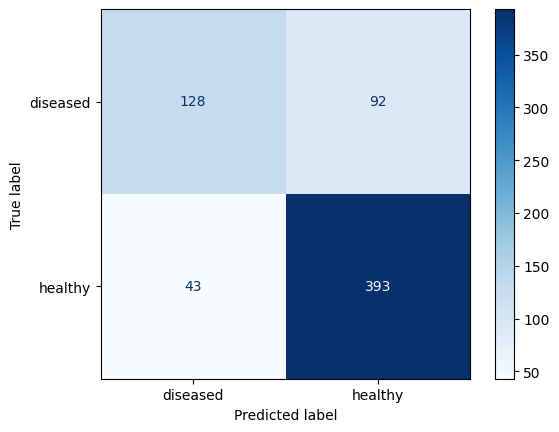

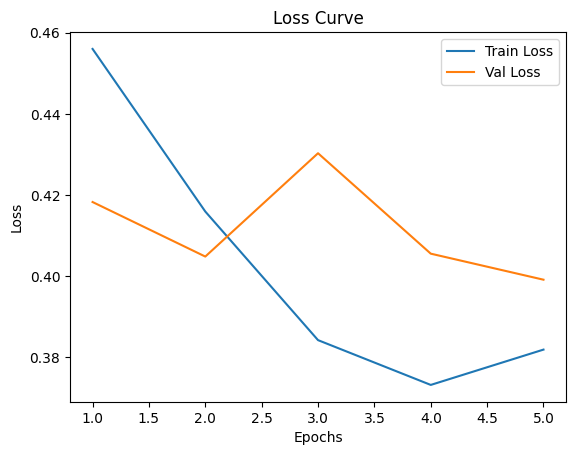

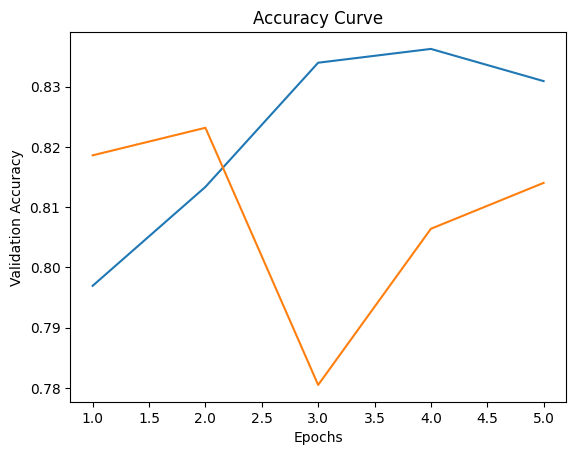

In [22]:
model, train_losses, train_accs, val_losses, val_accs = train_standard(dataset_, cfg)
plot_training_curves(train_losses, train_accs, val_losses, val_accs)

## Make prediction

In [23]:
from PIL import Image

def predict_single_image(image_path, model, transform, class_names, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, dim=1).item()

    print("Prediction:", class_names[pred])
    return class_names[pred]

In [24]:
import os
root = '../data_lionel/train_dataset'
class_sudir = 'diseased' #or 'diseased'
healthy =  'uplot_107001_1_camera_1_4_RGB_WB_V_U_1723524789_000_011.png'
diseased = 'uplot_107001_1_camera_1_4_RGB_WB_V_U_1723524789_001_006.png'

predict_single_image(
    os.path.join(root, class_sudir, diseased),
    model,
    val_transform,
    dataset_.classes,
    cfg.device
)

Prediction: diseased


'diseased'

## Simple GradCAM (Resnet18)

In [30]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))
        cam = torch.zeros(activations.shape[1:], device=activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [26]:
# target_layer = model.layer4[-1]
# target_layer

In [31]:
def show_gradcam(image_path, model, transform, device):

    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    target_layer = model.layer4[-1]

    for param in model.parameters():
        param.requires_grad = True
    
    model.eval()

    gradcam = GradCAM(model, target_layer)
    cam = gradcam.generate(input_tensor)

    gradcam.remove_hooks()  # IMPORTANT

    img = np.array(image.resize((224,224)))
    heatmap = cv2.resize(cam, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img
    superimposed = np.uint8(superimposed)

    plt.figure()
    plt.imshow(superimposed)
    plt.axis("off")
    plt.show()

In [32]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


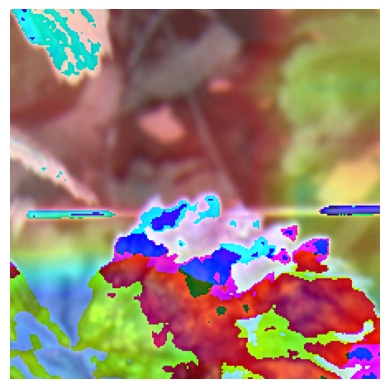

In [33]:
show_gradcam(
    image_path="../data_lionel/train_dataset/diseased/uplot_107001_1_camera_1_4_RGB_WB_V_U_1723524789_001_006.png",
    model=model,
    transform=val_transform,
    device=cfg.device
)

In [ ]:
# # Binary Segmentation
# # images .tif
# # masks .tif
# # save image + mask
# # 2 classes
# # conserve all patches


# import numpy as np
# import cv2
# from pathlib import Path
# import tifffile as tiff

# def extract_patches_from_folder(
#     images_dir: str,
#     masks_dir: str,
#     patch_size: int = 128,
#     output_base_dir: str = None
# ):

#     images_dir = Path(images_dir)
#     masks_dir = Path(masks_dir)

#     if output_base_dir is None:
#         output_base_dir = images_dir.parent / "extracted_patches"

#     output_base_dir = Path(output_base_dir)
#     images_out = output_base_dir / "images"
#     masks_out = output_base_dir / "masks"

#     images_out.mkdir(parents=True, exist_ok=True)
#     masks_out.mkdir(parents=True, exist_ok=True)

#     image_files = [f for f in images_dir.iterdir() if f.suffix.lower() in [".tif", ".tiff"]]

#     total = 0

#     for image_file in image_files:
#         mask_file = masks_dir / image_file.name

#         if not mask_file.exists():
#             print(f"Masque manquant pour {image_file.name}")
#             continue

#         # Lecture TIFF
#         img = tiff.imread(str(image_file))
#         mask = tiff.imread(str(mask_file))

#         H, W = mask.shape

#         n_rows = H // patch_size
#         n_cols = W // patch_size

#         for i in range(n_rows):
#             for j in range(n_cols):
#                 y0, x0 = i * patch_size, j * patch_size
#                 y1, x1 = y0 + patch_size, x0 + patch_size

#                 img_patch = img[y0:y1, x0:x1]
#                 mask_patch = mask[y0:y1, x0:x1]

#                 # Binarisation propre si nécessaire
#                 mask_patch = (mask_patch > 0).astype(np.uint8)

#                 name = f"{image_file.stem}_{i:03d}_{j:03d}.png"

#                 cv2.imwrite(str(images_out / name), img_patch)
#                 cv2.imwrite(str(masks_out / name), mask_patch * 255)

#                 total += 1

#     print(f"{total} patches sauvegardés.")